# 03 Area velocidad Media


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

FPS = 80  # cuadros por segundo del vídeo actual (80fps_black.tif)

vel = pd.read_pickle('../outputs/t_velocities.pkl')
print('muestras:', len(vel), '| partículas:', vel.particle.nunique())
vel[['particle','frame','x','y','vx','vy','v']].head()

muestras: 1765517 | partículas: 2069


,particle,frame,x,y,vx,vy,v
0,0,0,305.385844,39.044172,0.110561,0.283539,0.304332
348,0,1,305.578615,39.183303,0.081560,0.194146,0.210582
696,0,2,305.828678,39.741155,0.052559,0.104754,0.117199
1042,0,3,305.336158,39.138418,0.023557,0.015361,0.028123
1390,0,4,305.801738,39.733297,-0.000794,-0.038400,0.038408


Cantidad de velocidades:		  1765517
Cantidad de velocidades con v > 0.01:	  83168


<Axes: >

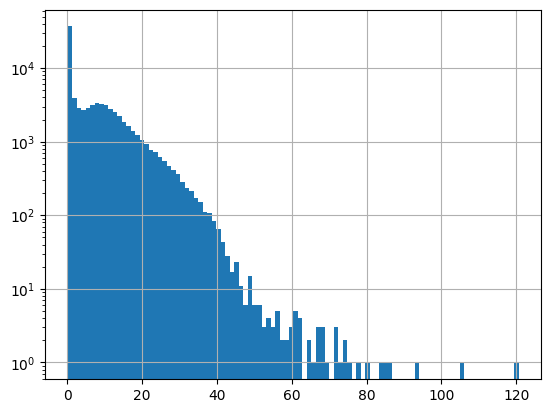

In [3]:
print("Cantidad de velocidades:\t\t ", vel.v.count())
print("Cantidad de velocidades con v > 0.01:\t ", vel.v[vel.v > 0.1].count())
vel.v[vel.v > 0.1].hist(bins=100, log=True)

## Metodo 1

In [4]:
'''
Dado el ruido que hace que las particulas tengan un maximo de velocidad muy alto, tomamos el percentil 95
Pero dado que las particulas estan quietas mucho tiempo, el percentil 95 quedaria muy bajo. Por eso filtramos las que tienen una velocidad chica (v > 0.1)cve'''
still_particle_noisy_speed = 0.1
v95 = vel.v[vel.v > still_particle_noisy_speed]\
    .quantile(0.95)

vel = vel[(vel.v > still_particle_noisy_speed)  & (vel.v < v95 * 0.8)]



In [5]:
from velocity_pipeline.velocity import extract_velocity_field
Px, Py, ctx, frames_list = extract_velocity_field(vel)




### Animación de campo: 

In [6]:
# tomamos el modulo de la velocidad para completar el tercer canal del video
all_speed = np.sqrt(Px**2 + Py**2)

NameError: name 'FuncAnimation' is not defined

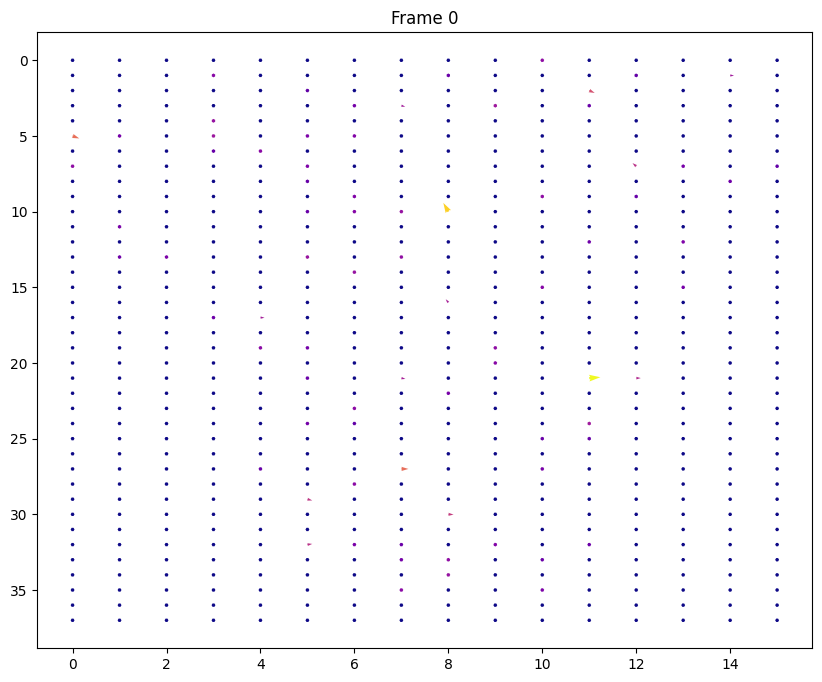

In [7]:
plt.rcParams['animation.embed_limit'] = 200
fig, ax = plt.subplots(figsize=(10, 8))
X, Y = np.meshgrid(np.arange(ctx['nx_bins']), np.arange(ctx['ny_bins']))

# angles='xy': dirección en coords de DATOS (respeta invert_yaxis). Con el default 'uv'
# las flechas ignoran la inversión y los pockets que caen salen apuntando arriba.
Q = ax.quiver(X, Y, Px[0], Py[0], all_speed[0], angles='xy',
              cmap="plasma", scale=40, width=0.005)
ax.invert_yaxis()
title = ax.set_title(f"Frame {frames_list[0]}")

def update(i):
    vx, vy, speed = Px[i], Py[i], all_speed[i]
    Q.set_UVC(vx, vy, speed)
    title.set_text(f"Frame {frames_list[i]}")
    return Q, title
    
ani = FuncAnimation(fig, update, frames=len(frames_list), interval=50, blit=True)
ani.save('../outputs/my_animation.mp4', writer='ffmpeg', fps=20)
plt.close()
HTML(ani.to_jshtml())